In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df = pd.read_csv("../data/Telco-Customer-Churn.csv")

In [15]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [16]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [17]:
df["Churn"].value_counts(normalize=True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

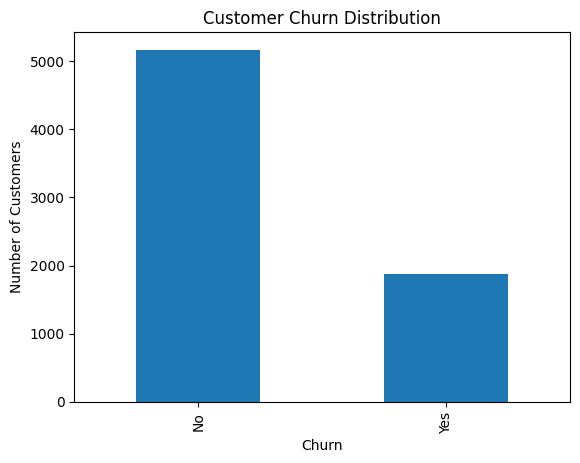

In [18]:
df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [19]:
pd.crosstab(df["gender"],df["Churn"])

Churn,No,Yes
gender,,
Female,2549,939
Male,2625,930


In [20]:
pd.crosstab(df["gender"],df["Churn"],normalize="index")*100

Churn,No,Yes
gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


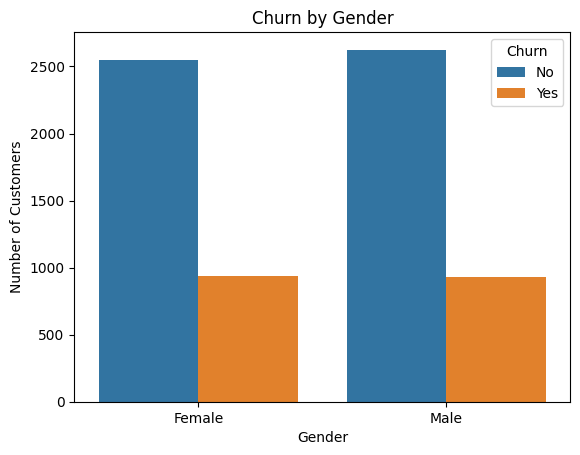

In [25]:
sns.countplot(data=df,x="gender",hue="Churn")
plt.title('Churn by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.show()

In [26]:
pd.crosstab(df["Contract"],df["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [27]:
pd.crosstab(df["Contract"],df["Churn"],normalize="index")*100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


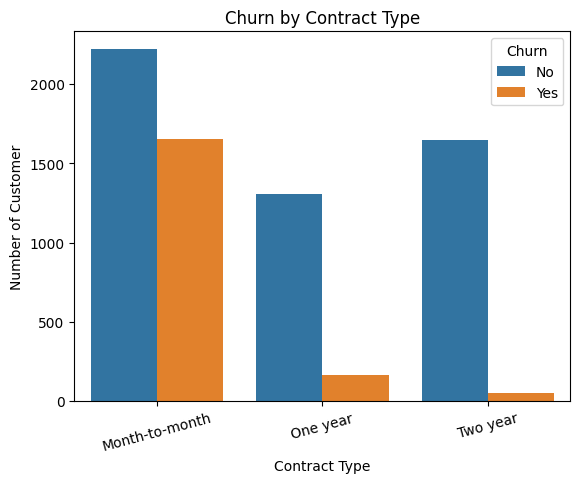

In [32]:
sns.countplot(data=df,x="Contract",hue="Churn")

plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customer")
plt.xticks(rotation=15)
plt.show()

In [33]:
df.groupby("Churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


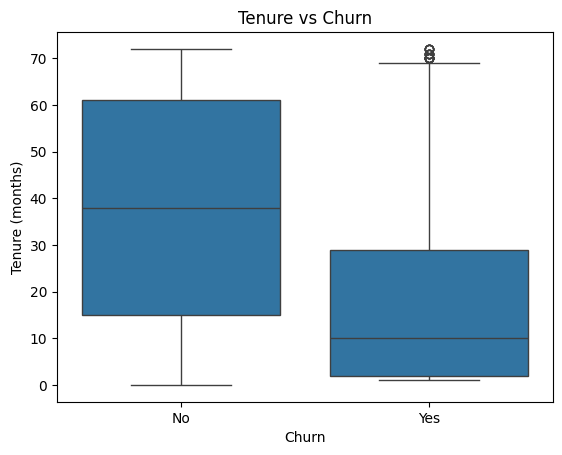

In [34]:
sns.boxplot(data=df,x="Churn",y="tenure")

plt.title("Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (months)")
plt.show()

In [38]:
df.groupby("Churn")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


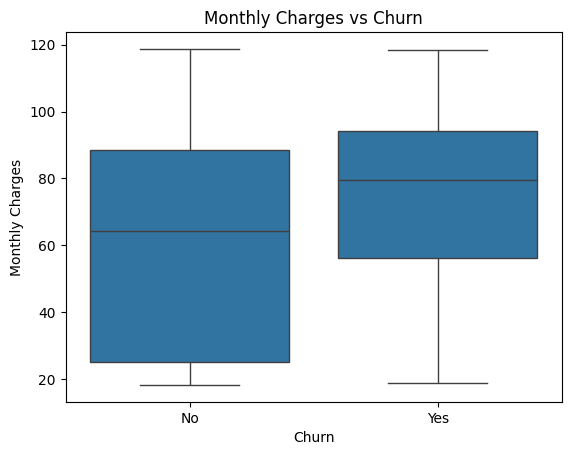

In [37]:
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

In [39]:
pd.crosstab(df["InternetService"],df["Churn"])

Churn,No,Yes
InternetService,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


In [40]:
pd.crosstab(df["InternetService"],df["Churn"],normalize="index")*100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


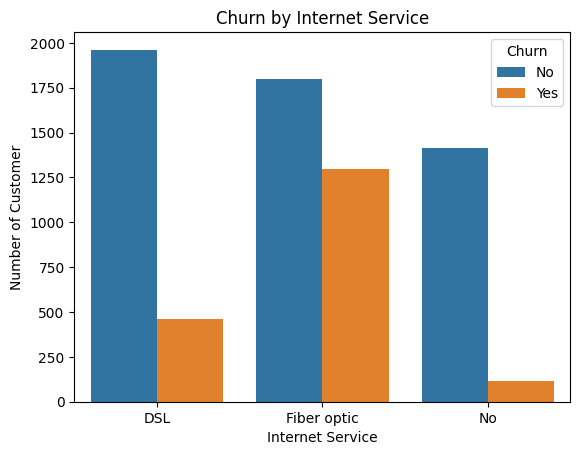

In [42]:
sns.countplot(data=df,x="InternetService",hue="Churn")

plt.title("Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customer")
plt.show()

In [43]:
pd.crosstab(df["PaymentMethod"],df["Churn"])

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


In [46]:
pd.crosstab(df["PaymentMethod"],df["Churn"],normalize="index")*100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


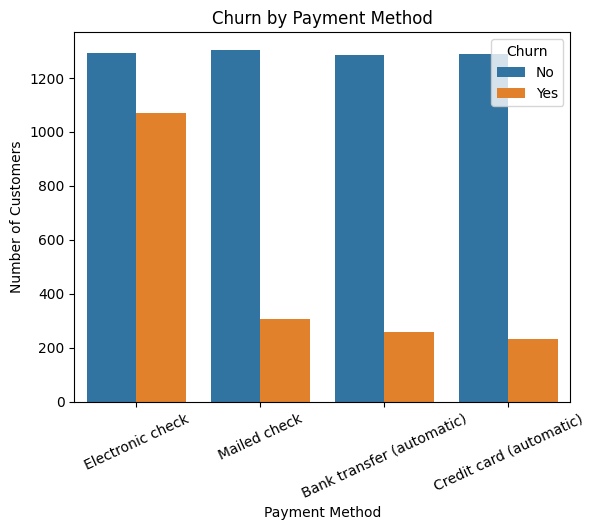

In [47]:
sns.countplot(data=df,x="PaymentMethod",hue="Churn")

plt.title("Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=25)
plt.show()

In [48]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=["0-12", "13-24", "25-48", "49-72"]
)

In [50]:
pd.crosstab([df["Contract"],df["tenure_group"]],df["Churn"],normalize="index")*100

Churn                                No        Yes
Contract       tenure_group                       
Month-to-month 0-12           48.645938  51.354062
               13-24          62.279512  37.720488
               25-48          67.082294  32.917706
               49-72          73.976608  26.023392
One year       0-12           89.516129  10.483871
               13-24          91.878173   8.121827
               25-48          89.382239  10.617761
               49-72          87.066246  12.933754
Two year       0-12          100.000000   0.000000
               13-24         100.000000   0.000000
               25-48          97.810219   2.189781
               49-72          96.674584   3.325416

In [51]:
pd.crosstab(df["TechSupport"],df["Churn"])

Churn,No,Yes
TechSupport,,
No,2027,1446
No internet service,1413,113
Yes,1734,310


In [52]:
pd.crosstab(df["TechSupport"],df["Churn"],normalize="index")*100

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


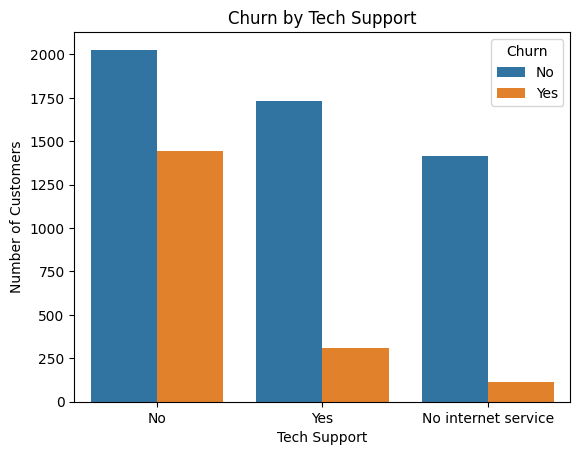

In [53]:
sns.countplot(data=df, x="TechSupport", hue="Churn")

plt.title("Churn by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Number of Customers")
plt.show()

In [54]:
pd.crosstab(df["OnlineSecurity"],df["Churn"])

Churn,No,Yes
OnlineSecurity,,
No,2037,1461
No internet service,1413,113
Yes,1724,295


In [55]:
pd.crosstab(
    df["OnlineSecurity"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
OnlineSecurity,,
No,58.233276,41.766724
No internet service,92.595020,7.404980
Yes,85.388806,14.611194


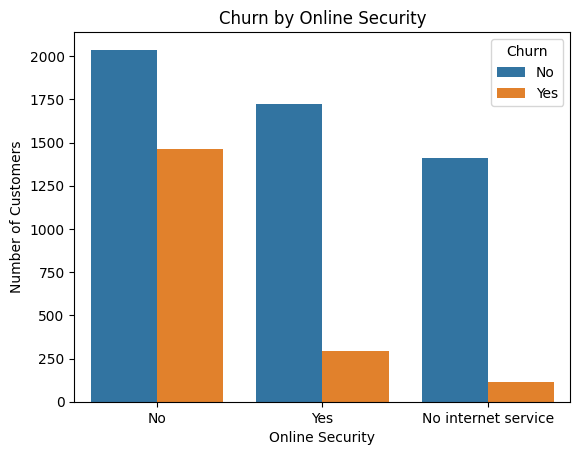

In [56]:
sns.countplot(data=df, x="OnlineSecurity", hue="Churn")

plt.title("Churn by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Number of Customers")
plt.show()

In [57]:
pd.crosstab(df["PaperlessBilling"], df["Churn"])

Churn,No,Yes
PaperlessBilling,,
No,2403,469
Yes,2771,1400


In [58]:
pd.crosstab(
    df["PaperlessBilling"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092


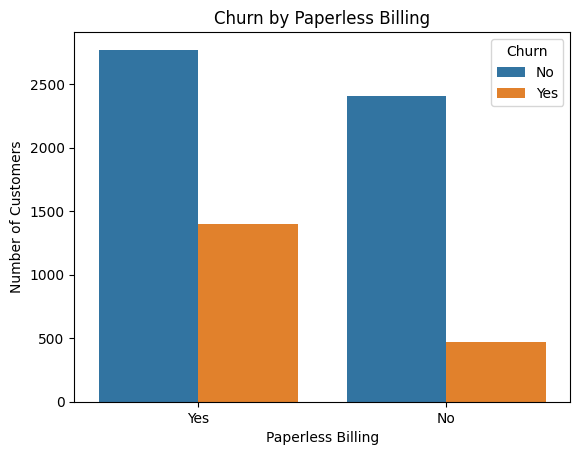

In [59]:
sns.countplot(data=df, x="PaperlessBilling", hue="Churn")

plt.title("Churn by Paperless Billing")
plt.xlabel("Paperless Billing")
plt.ylabel("Number of Customers")
plt.show()

In [60]:
df["TotalCharges_numeric"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [61]:
numeric_cols = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges_numeric"
]

df[numeric_cols].corr()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges_numeric
SeniorCitizen,1.000000,0.016567,0.220173,0.102411
tenure,0.016567,1.000000,0.247900,0.825880
MonthlyCharges,0.220173,0.247900,1.000000,0.651065
TotalCharges_numeric,0.102411,0.825880,0.651065,1.000000


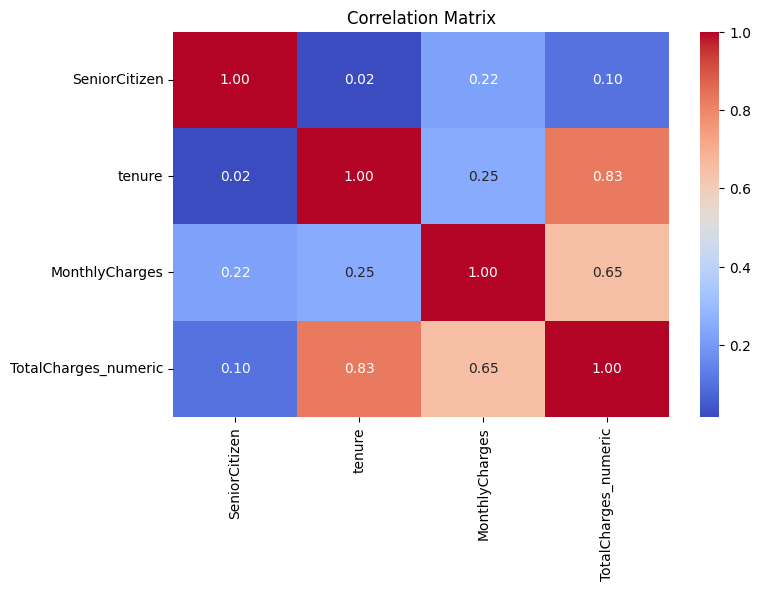

In [62]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()